In [92]:
import pandas as pd

In [93]:
original_narratvives_df = pd.read_csv('Catherine_man_redone.csv')
entity_classifications_df = pd.read_csv('Entity_Topic_Classifications_Catherine_man_detailed.csv')

In [94]:
original_narratvives_df

,cause_entity,effect_entity,relationship,document_reference,quantifications,modulator_uncertainty,modulator_temporal,tense,custom_id,speech_id,batch_id,speech_narrative_id
0,recent economic shocks,uncertainties around them,recent economic shocks create uncertainties,Catherine L Mann talks about the impact of rec...,NaN,NaN,NaN,PRESENT,speech_16649_batch_0,16649,batch_695a66a3679081909dffa72c9555fbdd,16649_0
1,near-term inflationary pressures,becoming embedded in domestic expectations and...,near-term inflationary pressures embed in expe...,"As I see it, the key balance of uncertainties ...",NaN,NaN,NaN,PRESENT,speech_16649_batch_0,16649,batch_695a66a3679081909dffa72c9555fbdd,16649_1
2,projected dramatic deterioration in real purch...,deterioration in real purchasing power of peop...,deterioration in purchasing power affects incomes,"As I see it, the key balance of uncertainties ...",NaN,NaN,near and medium term,FUTURE,speech_16649_batch_0,16649,batch_695a66a3679081909dffa72c9555fbdd,16649_2
3,monetary policy tools,short-circuit the inflationary expectations dy...,monetary policy tools can short-circuit inflat...,The challenge is to deploy monetary policy too...,NaN,NaN,now,PRESENT,speech_16649_batch_0,16649,batch_695a66a3679081909dffa72c9555fbdd,16649_3
4,monetary policy tools,prevent inflation from remaining above target,monetary policy tools prevent inflation from r...,The challenge is to deploy monetary policy too...,NaN,NaN,for longer,FUTURE,speech_16649_batch_0,16649,batch_695a66a3679081909dffa72c9555fbdd,16649_4
...,...,...,...,...,...,...,...,...,...,...,...,...
407,carbon price shock,affects green sector via spillover effects,Changes in carbon pricing indirectly impact th...,It is important to consider that the carbon pr...,NaN,NaN,NaN,NaN,speech_16655_batch_3,16655,batch_695a66ac6338819096be86723ff47895,16655_100
408,carbon prices,raise the cost of capital of emissions-intensi...,Higher carbon prices increase operational cost...,Hengge et al. (2023) also find that carbon pri...,NaN,NaN,NaN,PAST,speech_16655_batch_3,16655,batch_695a66ac6338819096be86723ff47895,16655_101
409,contractionary monetary policy shock,output declines,Tightening monetary policy reduces economic ac...,"After a contractionary monetary policy shock, ...",NaN,NaN,NaN,PAST,speech_16655_batch_3,16655,batch_695a66ac6338819096be86723ff47895,16655_102
410,output declines,reduces the demand for emissions,"Lower output decreases industrial activity, re...","After a contractionary monetary policy shock, ...",NaN,NaN,NaN,PAST,speech_16655_batch_3,16655,batch_695a66ac6338819096be86723ff47895,16655_103


In [95]:
entity_classifications_df

,entity,topic,classification,document_reference,custom_id,speech_id,location,request_idx,speech_narrative_id,entity_type,entity_speech_narrative_id
0,recent economic shocks,geopolitical shocks,higher,NaN,speech_16649_narr_16649_0_cause_0,16649,global,0,16649_0,cause,recent economic shocks|16649_0
1,uncertainties around them,geopolitical shocks,higher,NaN,speech_16649_narr_16649_0_effect_0,16649,global,0,16649_0,effect,uncertainties around them|16649_0
2,near-term inflationary pressures,inflation,higher,NaN,speech_16649_narr_16649_1_cause_1,16649,domestic,1,16649_1,cause,near-term inflationary pressures|16649_1
3,becoming embedded in domestic expectations and...,inflation,higher,NaN,speech_16649_narr_16649_1_effect_1,16649,domestic,1,16649_1,effect,becoming embedded in domestic expectations and...
4,projected dramatic deterioration in real purch...,output,lower,NaN,speech_16649_narr_16649_2_cause_2,16649,domestic,2,16649_2,cause,projected dramatic deterioration in real purch...
...,...,...,...,...,...,...,...,...,...,...,...
826,output declines,output,lower,NaN,speech_16655_narr_16655_102_effect_409,16655,domestic,409,16655_102,effect,output declines|16655_102
827,output declines,output,lower,NaN,speech_16655_narr_16655_103_cause_410,16655,domestic,410,16655_103,cause,output declines|16655_103
828,demand for emissions,output,lower,NaN,speech_16655_narr_16655_103_effect_410,16655,domestic,410,16655_103,effect,demand for emissions|16655_103
829,fall in price under the ETS,other,lower,NaN,speech_16655_narr_16655_104_cause_411,16655,global,411,16655_104,cause,fall in price under the ETS|16655_104


In [105]:
# merge entity classifications to have [entity_name, entity_topic, entity_classification] merged to the original narratives by the speech_narrative_id and entity_type (cause/effect)
# original_narratvives_df does not have a entity_type column, so we first merge the cause entities then merge the effect entities

completed_entities_df = original_narratvives_df.merge(
    entity_classifications_df[entity_classifications_df['entity_type']=='cause'][['speech_narrative_id','entity', 'topic', 'classification', 'location']],
    left_on=['speech_narrative_id'],
    right_on=['speech_narrative_id'],
    how='left'
) 

completed_entities_df = completed_entities_df.merge(
    entity_classifications_df[entity_classifications_df['entity_type']=='effect'][['speech_narrative_id','entity', 'topic', 'classification', 'location']],
    left_on=['speech_narrative_id'],
    right_on=['speech_narrative_id'],
    how='left',
    suffixes=('_cause', '_effect')
)   





In [106]:
completed_entities_df[['cause_entity','topic_cause','classification_cause']].value_counts()

cause_entity                     topic_cause        classification_cause
monetary policy                  interest rates     normal                  9
inflation expectations drift up  inflation          higher                  7
US tightening                    interest rates     higher                  7
climate change                   other              higher                  6
investment and subsidies         output             higher                  4
                                                                           ..
falling equilibrium rate         interest rates     lower                   1
falling equity risk premium      financial markets  lower                   1
falling real rate                interest rates     lower                   1
financial conditions             financial markets  normal                  1
yield curve inversion            interest rates     higher                  1
Name: count, Length: 313, dtype: int64

In [107]:
completed_entities_df['classification_cause'].value_counts()

classification_cause
higher    273
normal     83
lower      63
Name: count, dtype: int64

In [108]:
completed_entities_df[['effect_entity','topic_effect','classification_effect']].value_counts()

effect_entity                                                         topic_effect       classification_effect
inflationary effects                                                  inflation          higher                   6
increase in output                                                    output             higher                   4
Sterling depreciation                                                 exchange rate      lower                    3
0.15% peak increase in CPI                                            inflation          higher                   2
real rate increases                                                   interest rates     higher                   2
                                                                                                                 ..
extend duration of time above 2% target                               inflation          higher                   1
expectations of price changes over the next 12 months have increased  inflati

In [109]:
import networkx as nx
import matplotlib.pyplot as plt


In [110]:
# put the previous networkx graph code into a function that takes in the completed_entities_df and outputs the graph
def plot_entity_graph(completed_entities_df, 
                      cause_col='cause_entity',
                      effect_col='effect_entity', 
                      cause_topic_col='topic_cause',
                      effect_topic_col='topic_effect',
                      cause_classification_col='classification_cause',
                      effect_classification_col='classification_effect'):
    """
    Plots an entity graph showing causal relationships between entities.
    
    Parameters:
    -----------
    completed_entities_df : pd.DataFrame
        The dataframe containing entity relationships
    cause_col : str
        Column name for cause entities (default: 'cause_entity')
    effect_col : str
        Column name for effect entities (default: 'effect_entity')
    cause_topic_col : str
        Column name for cause topics (default: 'topic_cause')
    effect_topic_col : str
        Column name for effect topics (default: 'topic_effect')
    cause_classification_col : str
        Column name for cause classifications (default: 'classification_cause')
    effect_classification_col : str
        Column name for effect classifications (default: 'classification_effect')
    """
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    import networkx as nx
    G = nx.DiGraph()
    # Build nodes and edges with safe defaults
    for _, row in completed_entities_df.iterrows():
        cause = row.get(cause_col)
        effect = row.get(effect_col)
        cause_topic = row.get(cause_topic_col)
        effect_topic = row.get(effect_topic_col)
        cause_classification = row.get(cause_classification_col)
        effect_classification = row.get(effect_classification_col)
        # Add nodes only if entity is present
        if pd.notna(cause):
            G.add_node(
                cause,
                topic=str(cause_topic).lower() if pd.notna(cause_topic) else 'other',
                classification=str(cause_classification).lower() if pd.notna(cause_classification) else 'normal',
            )
        if pd.notna(effect):
            G.add_node(
                effect,
                topic=str(effect_topic).lower() if pd.notna(effect_topic) else 'other',
                classification=str(effect_classification).lower() if pd.notna(effect_classification) else 'normal',
            )
        # Add edge only if both are present
        if pd.notna(cause) and pd.notna(effect):
            G.add_edge(cause, effect)
    # If no nodes, short-circuit
    if G.number_of_nodes() == 0:
        print('No nodes to plot (empty graph).')
        return
    # Topic color mapping (lowercase keys)
    # fir each topic in 'inflation',  'output', #'inflation/output tradeoffs',
    # 'labour market', 'interest rates',
    # 'government spending','exchange rate', 'housing market',
    # 'credit', 'financial markets','geopolitical shocks', 'trade', #'central bank communication',
    # 'productivity', 'other',
    topic_color_map = {
        'inflation': 'red',
        'output': 'blue',
        #'inflation/output tradeoffs': 'purple',
        'labour market': 'orange',
        'interest rates': 'green',
        'government spending': 'brown',
        'exchange rate': 'pink',
        'housing market': 'gray',
        'credit': 'olive',
        'financial markets': 'cyan',
        'geopolitical shocks': 'magenta',
        'trade': 'yellow',
        #'central bank communication': 'teal',
        'productivity': 'navy',
        'other': 'lightgray',
        
    }
    # Classification -> shape
    classification_shape_map = {
        'higher': '^',
        'normal': 's',
        'lower': 'v',
    }
    # Build per-node colors using topic
    node_colors: dict[str, str] = {}
    for n, data in G.nodes(data=True):
        topic = str(data.get('topic', 'other')).lower()
        node_colors[n] = topic_color_map.get(topic, topic_color_map['other'])
    # Build per-node shapes using classification
    node_shapes: list[str] = []
    for n, data in G.nodes(data=True):
        cls = str(data.get('classification', 'normal')).lower()
        node_shapes.append(classification_shape_map.get(cls, 'o'))
    # Draw
    plt.figure(figsize=(12, 12))
    pos = nx.spring_layout(G, k=0.5)
    # Group nodes by shape and draw
    for shape in set(node_shapes):
        shaped_nodes = [n for n, d in G.nodes(data=True) if classification_shape_map.get(str(d.get('classification', 'normal')).lower(), 'o') == shape]
        if not shaped_nodes:
            continue
        colors = [node_colors[n] for n in shaped_nodes]
        nx.draw_networkx_nodes(
            G, pos,
            nodelist=shaped_nodes,
            node_color=colors,
            node_shape=shape,
            edgecolors='black',
        )
    nx.draw_networkx_edges(G, pos, arrows=True)
    nx.draw_networkx_labels(G, pos, font_size=8)
    # Add legend for topic colors
    color_handles = [Patch(facecolor=color, edgecolor='black', label=topic) for topic, color in topic_color_map.items()]
    plt.legend(handles=color_handles, title='Topics', bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.axis('off')
    plt.tight_layout()
    plt.show()


In [111]:
# make the same function but for each subgraph in the graph above 


In [112]:
def plot_entity_subgraphs(completed_entities_df,
                          cause_col='cause_entity',
                          effect_col='effect_entity',
                          cause_topic_col='topic_cause',
                          effect_topic_col='topic_effect',
                          cause_classification_col='classification_cause',
                          effect_classification_col='classification_effect'):
    """
    Plots each connected component (subgraph) of the entity graph separately.
    
    Parameters:
    -----------
    completed_entities_df : pd.DataFrame
        The dataframe containing entity relationships
    cause_col : str
        Column name for cause entities (default: 'cause_entity')
    effect_col : str
        Column name for effect entities (default: 'effect_entity')
    cause_topic_col : str
        Column name for cause topics (default: 'topic_cause')
    effect_topic_col : str
        Column name for effect topics (default: 'topic_effect')
    cause_classification_col : str
        Column name for cause classifications (default: 'classification_cause')
    effect_classification_col : str
        Column name for effect classifications (default: 'classification_effect')
    """
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.patches import Patch
    import networkx as nx
    
    G = nx.DiGraph()
    
    # Build nodes and edges with safe defaults
    for _, row in completed_entities_df.iterrows():
        cause = row.get(cause_col)
        effect = row.get(effect_col)
        cause_topic = row.get(cause_topic_col)
        effect_topic = row.get(effect_topic_col)
        cause_classification = row.get(cause_classification_col)
        effect_classification = row.get(effect_classification_col)
        
        # Add nodes only if entity is present
        if pd.notna(cause):
            G.add_node(
                cause,
                topic=str(cause_topic).lower() if pd.notna(cause_topic) else 'other',
                classification=str(cause_classification).lower() if pd.notna(cause_classification) else 'normal',
            )
        if pd.notna(effect):
            G.add_node(
                effect,
                topic=str(effect_topic).lower() if pd.notna(effect_topic) else 'other',
                classification=str(effect_classification).lower() if pd.notna(effect_classification) else 'normal',
            )
        
        # Add edge only if both are present
        if pd.notna(cause) and pd.notna(effect):
            G.add_edge(cause, effect)
    
    # If no nodes, short-circuit
    if G.number_of_nodes() == 0:
        print('No nodes to plot (empty graph).')
        return
    
    # Get weakly connected components (treating directed graph as undirected for components)
    subgraphs = [G.subgraph(c).copy() for c in nx.weakly_connected_components(G)]
    
    print(f"Found {len(subgraphs)} connected component(s)")
    
    # Topic color mapping
    topic_color_map = {
        'inflation': 'red',
        'output': 'blue',
        'labour market': 'orange',
        'interest rates': 'green',
        'government spending': 'brown',
        'exchange rate': 'pink',
        'housing market': 'gray',
        'credit': 'olive',
        'financial markets': 'cyan',
        'geopolitical shocks': 'magenta',
        'trade': 'yellow',
        'productivity': 'navy',
        'other': 'lightgray',
    }
    
    # Classification -> shape
    classification_shape_map = {
        'higher': '^',
        'normal': 's',
        'lower': 'v',
    }
    
    # Plot each subgraph
    for idx, subG in enumerate(subgraphs, 1):
        if subG.number_of_nodes() == 0:
            continue
            
        print(f"\nSubgraph {idx}: {subG.number_of_nodes()} nodes, {subG.number_of_edges()} edges")
        
        # Build per-node colors using topic
        node_colors = {}
        for n, data in subG.nodes(data=True):
            topic = str(data.get('topic', 'other')).lower()
            node_colors[n] = topic_color_map.get(topic, topic_color_map['other'])
        
        # Build per-node shapes using classification
        node_shapes = []
        for n, data in subG.nodes(data=True):
            cls = str(data.get('classification', 'normal')).lower()
            node_shapes.append(classification_shape_map.get(cls, 'o'))
        
        # Draw
        plt.figure(figsize=(10, 10))
        pos = nx.spring_layout(subG, k=0.5)
        
        # Group nodes by shape and draw
        for shape in set(node_shapes):
            shaped_nodes = [n for n, d in subG.nodes(data=True) 
                          if classification_shape_map.get(str(d.get('classification', 'normal')).lower(), 'o') == shape]
            if not shaped_nodes:
                continue
            colors = [node_colors[n] for n in shaped_nodes]
            nx.draw_networkx_nodes(
                subG, pos,
                nodelist=shaped_nodes,
                node_color=colors,
                node_shape=shape,
                edgecolors='black',
            )
        
        nx.draw_networkx_edges(subG, pos, arrows=True)
        nx.draw_networkx_labels(subG, pos, font_size=8)
        
        # Add legend for topic colors
        color_handles = [Patch(facecolor=color, edgecolor='black', label=topic) 
                        for topic, color in topic_color_map.items()]
        plt.legend(handles=color_handles, title='Topics', bbox_to_anchor=(1.02, 1), loc='upper left')
        
        plt.title(f'Subgraph {idx}')
        plt.axis('off')
        plt.tight_layout()
        plt.show()


In [115]:
# Make a merge of the nodes that are of the same topic and classification together 

def merge_entities_by_topic_classification(completed_entities_df):
    """
    Merges entities that have the same topic and classification across different narratives.
    Creates a new dataframe with merged entity names and tracks the original entities.
    
    Returns:
        merged_df: DataFrame with merged entity names
        entity_mapping: Dictionary tracking which original entities were merged together
    """
    import pandas as pd
    
    # Create a copy to avoid modifying the original
    df = completed_entities_df.copy()
    
    # Track mappings for both cause and effect entities
    cause_mapping = {}
    effect_mapping = {}
    
    # Get unique combinations of topic and classification for causes
    cause_combos = df[['topic_cause', 'classification_cause','location_cause']].dropna().drop_duplicates()
    
    for _, row in cause_combos.iterrows():
        topic = row['topic_cause']
        classification = row['classification_cause']
        location = row['location_cause']
        
        # Find all unique cause entities with this topic and classification
        mask = (df['topic_cause'] == topic) & (df['classification_cause'] == classification) & (df['location_cause'] == location)
        original_entities = df.loc[mask, 'entity_cause'].dropna().unique().tolist()
        
        if len(original_entities) > 0:
            # Create merged entity name
            merged_name = f"{topic}_{classification}_{location}"
            cause_mapping[merged_name] = original_entities
            
            # Replace all matching entities with the merged name
            df.loc[mask, 'entity_cause'] = merged_name
    
    # Get unique combinations of topic and classification for effects
    effect_combos = df[['topic_effect', 'classification_effect','location_effect']].dropna().drop_duplicates()
    
    for _, row in effect_combos.iterrows():
        topic = row['topic_effect']
        classification = row['classification_effect']
        location = row['location_effect']
        
        # Find all unique effect entities with this topic and classification
        mask = (df['topic_effect'] == topic) & (df['classification_effect'] == classification) & (df['location_effect'] == location)
        original_entities = df.loc[mask, 'entity_effect'].dropna().unique().tolist()
        
        if len(original_entities) > 0:
            # Create merged entity name
            merged_name = f"{topic}_{classification}_{location}"
            effect_mapping[merged_name] = original_entities
            
            # Replace all matching entities with the merged name
            df.loc[mask, 'entity_effect'] = merged_name
    
    # Combine mappings and show summary
    all_mappings = {}
    for merged, originals in cause_mapping.items():
        if merged not in all_mappings:
            all_mappings[merged] = {'cause': [], 'effect': []}
        all_mappings[merged]['cause'] = originals
    
    for merged, originals in effect_mapping.items():
        if merged not in all_mappings:
            all_mappings[merged] = {'cause': [], 'effect': []}
        all_mappings[merged]['effect'] = originals
    
    # Print summary
    print(f"Merged entities summary:")
    print(f"Total merged entity types: {len(all_mappings)}")
    print("\nMerged entity mappings:")
    for merged_name, mapping in sorted(all_mappings.items()):
        cause_count = len(mapping['cause'])
        effect_count = len(mapping['effect'])
        if cause_count > 0:
            print(f"\n{merged_name} (CAUSE) - merged {cause_count} entities:")
            for orig in mapping['cause'][:5]:  # Show first 5
                print(f"  - {orig}")
            if cause_count > 5:
                print(f"  ... and {cause_count - 5} more")
        if effect_count > 0:
            print(f"\n{merged_name} (EFFECT) - merged {effect_count} entities:")
            for orig in mapping['effect'][:5]:  # Show first 5
                print(f"  - {orig}")
            if effect_count > 5:
                print(f"  ... and {effect_count - 5} more")
    
    return df, all_mappings

# Apply the merge
merged_entities_df, entity_mappings = merge_entities_by_topic_classification(completed_entities_df)

Merged entities summary:
Total merged entity types: 57

Merged entity mappings:

credit_higher_domestic (CAUSE) - merged 1 entities:
  - subsidies for green loans to banks

credit_higher_global (CAUSE) - merged 1 entities:
  - high debt levels

credit_higher_global (EFFECT) - merged 1 entities:
  - high debt levels

credit_lower_domestic (CAUSE) - merged 2 entities:
  - traditional central bank tools for lending to banks
  - borrowing on central bank terms

credit_normal_domestic (CAUSE) - merged 3 entities:
  - credit shocks
  - lending directly to NBFIs against high quality collateral
  - bank lending tools

exchange rate_higher_domestic (CAUSE) - merged 4 entities:
  - appreciation of Sterling
  - Depreciation makes exports from this country more attractive
  - depreciation pressure on Sterling
  - persistent UK-specific risk premium

exchange rate_higher_domestic (EFFECT) - merged 3 entities:
  - Sterling depreciation
  - depreciation pressure on Sterling
  - appreciates the Sterli

In [114]:
completed_entities_df

,cause_entity,effect_entity,relationship,document_reference,quantifications,modulator_uncertainty,modulator_temporal,tense,custom_id,speech_id,batch_id,speech_narrative_id,entity_cause,topic_cause,classification_cause,location_cause,entity_effect,topic_effect,classification_effect,location_effect
0,recent economic shocks,uncertainties around them,recent economic shocks create uncertainties,Catherine L Mann talks about the impact of rec...,NaN,NaN,NaN,PRESENT,speech_16649_batch_0,16649,batch_695a66a3679081909dffa72c9555fbdd,16649_0,recent economic shocks,geopolitical shocks,higher,global,uncertainties around them,geopolitical shocks,higher,global
1,near-term inflationary pressures,becoming embedded in domestic expectations and...,near-term inflationary pressures embed in expe...,"As I see it, the key balance of uncertainties ...",NaN,NaN,NaN,PRESENT,speech_16649_batch_0,16649,batch_695a66a3679081909dffa72c9555fbdd,16649_1,near-term inflationary pressures,inflation,higher,domestic,becoming embedded in domestic expectations and...,inflation,higher,domestic
2,projected dramatic deterioration in real purch...,deterioration in real purchasing power of peop...,deterioration in purchasing power affects incomes,"As I see it, the key balance of uncertainties ...",NaN,NaN,near and medium term,FUTURE,speech_16649_batch_0,16649,batch_695a66a3679081909dffa72c9555fbdd,16649_2,projected dramatic deterioration in real purch...,output,lower,domestic,deterioration in real purchasing power of peop...,output,lower,domestic
3,monetary policy tools,short-circuit the inflationary expectations dy...,monetary policy tools can short-circuit inflat...,The challenge is to deploy monetary policy too...,NaN,NaN,now,PRESENT,speech_16649_batch_0,16649,batch_695a66a3679081909dffa72c9555fbdd,16649_3,monetary policy tools,interest rates,higher,domestic,short-circuit the inflationary expectations dy...,inflation,higher,domestic
4,monetary policy tools,prevent inflation from remaining above target,monetary policy tools prevent inflation from r...,The challenge is to deploy monetary policy too...,NaN,NaN,for longer,FUTURE,speech_16649_batch_0,16649,batch_695a66a3679081909dffa72c9555fbdd,16649_4,monetary policy tools,interest rates,higher,domestic,inflation,inflation,higher,domestic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
414,carbon price shock,affects green sector via spillover effects,Changes in carbon pricing indirectly impact th...,It is important to consider that the carbon pr...,NaN,NaN,NaN,NaN,speech_16655_batch_3,16655,batch_695a66ac6338819096be86723ff47895,16655_100,carbon price shock,other,higher,domestic,affects green sector via spillover effects,other,normal,domestic
415,carbon prices,raise the cost of capital of emissions-intensi...,Higher carbon prices increase operational cost...,Hengge et al. (2023) also find that carbon pri...,NaN,NaN,NaN,PAST,speech_16655_batch_3,16655,batch_695a66ac6338819096be86723ff47895,16655_101,carbon prices,other,higher,global,raise the cost of capital of emissions-intensi...,financial markets,higher,global
416,contractionary monetary policy shock,output declines,Tightening monetary policy reduces economic ac...,"After a contractionary monetary policy shock, ...",NaN,NaN,NaN,PAST,speech_16655_batch_3,16655,batch_695a66ac6338819096be86723ff47895,16655_102,contractionary monetary policy shock,interest rates,higher,domestic,output declines,output,lower,domestic
417,output declines,reduces the demand for emissions,"Lower output decreases industrial activity, re...","After a contractionary monetary policy shock, ...",NaN,NaN,NaN,PAST,speech_16655_batch_3,16655,batch_695a66ac6338819096be86723ff47895,16655_103,output declines,output,lower,domestic,demand for emissions,output,lower,domestic


In [116]:
entity_mappings

{'geopolitical shocks_higher_global': {'cause': ['recent economic shocks',
   'energy price shock',
   'oil prices',
   'oil prices jumped to 10 US Dollars per barrel',
   'sudden onset of Covid lockdown',
   'climate change',
   'carbon supply shock',
   'carbon price shock',
   'sequence of anticipated carbon price shocks',
   'anticipated carbon price shocks'],
  'effect': ['uncertainties around them',
   'increased risk of being in the purple world']},
 'inflation_higher_domestic': {'cause': ['near-term inflationary pressures',
   'shocks',
   'expectations by workers and firms for wage increases and price increases',
   '2021 wage settlements and price hikes',
   'increase in inflation expectations',
   'firms pricing expectations',
   'repeated shocks on the same side',
   'shocks over the past year',
   'consumer expectations for aggregate inflation',
   'monetary policy that looks through price changes',
   'inflation ratchet',
   'high inflation',
   'Ofgem price cap',
   'dou

In [117]:
speech_df.columns

Index(['cause_entity', 'effect_entity', 'relationship', 'document_reference',
       'quantifications', 'modulator_uncertainty', 'modulator_temporal',
       'tense', 'custom_id', 'speech_id', 'batch_id', 'speech_narrative_id',
       'entity_cause', 'topic_cause', 'classification_cause', 'entity_effect',
       'topic_effect', 'classification_effect'],
      dtype='object')

In [120]:
merged_entities_df[merged_entities_df['entity_effect']=='geopolitical shocks_higher_global']

,cause_entity,effect_entity,relationship,document_reference,quantifications,modulator_uncertainty,modulator_temporal,tense,custom_id,speech_id,batch_id,speech_narrative_id,entity_cause,topic_cause,classification_cause,location_cause,entity_effect,topic_effect,classification_effect,location_effect
0,recent economic shocks,uncertainties around them,recent economic shocks create uncertainties,Catherine L Mann talks about the impact of rec...,NaN,NaN,NaN,PRESENT,speech_16649_batch_0,16649,batch_695a66a3679081909dffa72c9555fbdd,16649_0,geopolitical shocks_higher_global,geopolitical shocks,higher,global,geopolitical shocks_higher_global,geopolitical shocks,higher,global
265,sequence of large inflationary shocks,increased risk of being in the purple world,A sequence of large inflationary shocks increa...,We have to remember that the world has been hi...,NaN,NaN,NaN,PAST,speech_16653_batch_2,16653,batch_695a66aaa74c81908916927aba923bea,16653_43,inflation_higher_global,inflation,higher,global,geopolitical shocks_higher_global,geopolitical shocks,higher,global


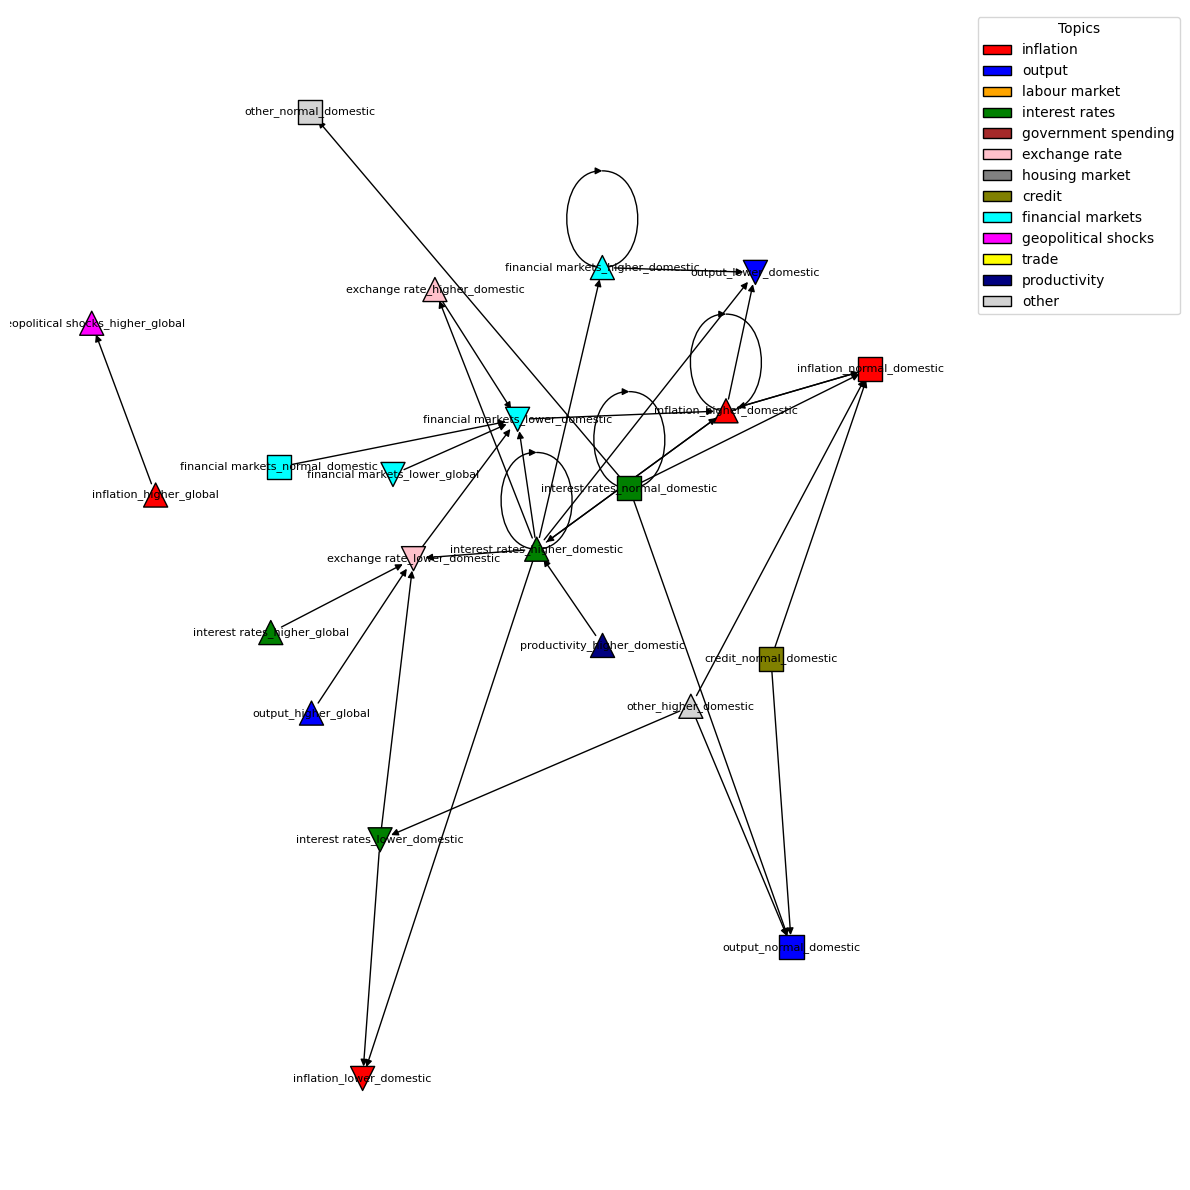

In [118]:
# For a specific speech
speech_df = merged_entities_df[merged_entities_df['speech_id'] == 16653]
plot_entity_graph(speech_df,

cause_col='entity_cause',
effect_col='entity_effect', 
cause_topic_col='topic_cause',
effect_topic_col='topic_effect',
cause_classification_col='classification_cause',
effect_classification_col='classification_effect'
                      
                      )

In [ ]:
# Or plot subgraphs with merged entities
plot_entity_subgraphs(speech_df,
                      cause_col='entity_cause',
                      effect_col='entity_effect')

In [ ]:
# For merged dataframe, specify the correct column names
# Note: merged_entities_df uses 'entity_cause' and 'entity_effect' instead of 'cause_entity' and 'effect_entity'
speech_df = merged_entities_df[merged_entities_df['speech_id'] == 16653]
plot_entity_graph(speech_df, 
                  cause_col='entity_cause',
                  effect_col='entity_effect')

In [124]:
speech_df

,cause_entity,effect_entity,relationship,document_reference,quantifications,modulator_uncertainty,modulator_temporal,tense,custom_id,speech_id,batch_id,speech_narrative_id,entity_cause,topic_cause,classification_cause,location_cause,entity_effect,topic_effect,classification_effect,location_effect
221,changes in monetary policy,changes in inflation,changes in monetary policy take 18 to 24 month...,"In the central banking world, 18 to 24 months ...",18 to 24 months,NaN,over that timeframe,PRESENT,speech_16653_batch_0,16653,batch_695a66aaa74c81908916927aba923bea,16653_0,interest rates_normal_domestic,interest rates,normal,domestic,inflation_normal_domestic,inflation,normal,domestic
222,changes in monetary policy,changes in inflation,changes in monetary policy take 18 to 24 month...,"In the central banking world, 18 to 24 months ...",18 to 24 months,NaN,NaN,PRESENT,speech_16653_batch_0,16653,batch_695a66aaa74c81908916927aba923bea,16653_1,interest rates_normal_domestic,interest rates,normal,domestic,inflation_normal_domestic,inflation,normal,domestic
223,raising Bank Rate,tightening of monetary conditions,raising Bank Rate tightens monetary conditions,"Over the last year and a half, monetary condit...",NaN,NaN,over a short period of time,PAST,speech_16653_batch_0,16653,batch_695a66aaa74c81908916927aba923bea,16653_2,interest rates_higher_domestic,interest rates,higher,domestic,interest rates_higher_domestic,interest rates,higher,domestic
224,tightening in financial conditions,households cut back on consumption,tightening in financial conditions increases b...,"But to start the transmission process, a tight...",NaN,should,NaN,PRESENT,speech_16653_batch_0,16653,batch_695a66aaa74c81908916927aba923bea,16653_3,financial markets_higher_domestic,financial markets,higher,domestic,output_lower_domestic,output,lower,domestic
225,tightening in financial conditions,firms reduce investment,tightening in financial conditions increases b...,"Firms may reduce investment, both in response ...",NaN,may,NaN,PRESENT,speech_16653_batch_0,16653,batch_695a66aaa74c81908916927aba923bea,16653_4,financial markets_higher_domestic,financial markets,higher,domestic,output_lower_domestic,output,lower,domestic
226,higher interest rates,downward effect on equity prices,higher interest rates increase the discount fa...,The MPCs tightening in monetary policy has had...,NaN,NaN,over the last twelve months,PAST,speech_16653_batch_0,16653,batch_695a66aaa74c81908916927aba923bea,16653_5,interest rates_higher_domestic,interest rates,higher,domestic,financial markets_lower_domestic,financial markets,lower,domestic
227,shareholder payout,positive contribution to equity prices,shareholder payout increases equity prices by ...,"But Chart 4 shows that, in fact, shareholder p...",NaN,NaN,since the beginning of last year,PAST,speech_16653_batch_1,16653,batch_695a66aaa74c81908916927aba923bea,16653_6,financial markets_higher_domestic,financial markets,higher,domestic,financial markets_higher_domestic,financial markets,higher,domestic
228,equity risk premium,positive contribution to equity prices,equity risk premium increases equity prices by...,"But Chart 4 shows that, in fact, shareholder p...",NaN,NaN,since the beginning of last year,PAST,speech_16653_batch_1,16653,batch_695a66aaa74c81908916927aba923bea,16653_7,financial markets_higher_domestic,financial markets,higher,domestic,financial markets_higher_domestic,financial markets,higher,domestic
229,monetary policy tightening through interest rates,effects on equity prices,monetary policy tightening through interest ra...,These have outweighed the effects of monetary ...,NaN,NaN,NaN,PAST,speech_16653_batch_1,16653,batch_695a66aaa74c81908916927aba923bea,16653_8,interest rates_higher_domestic,interest rates,higher,domestic,financial markets_lower_domestic,financial markets,lower,domestic
230,MPC's tightening efforts,offset by equity risk premium,MPC's tightening efforts are offset by equity ...,It seems that the MPCs tightening effo

In [125]:
speech_df[['cause_entity','relationship','effect_entity','document_reference']].values

array([['changes in monetary policy',
        'changes in monetary policy take 18 to 24 months to affect inflation',
        'changes in inflation',
        'In the central banking world, 18 to 24 months is often quoted as how long it takes for changes in monetary policy to feed through to inflation, even as certainly this effect accumulates over that timeframe.'],
       ['changes in monetary policy',
        'changes in monetary policy take 18 to 24 months to affect inflation',
        'changes in inflation',
        'In the central banking world, 18 to 24 months is often quoted as how long it takes for changes in monetary policy to feed through to inflation, even as certainly this effect accumulates over that timeframe.'],
       ['raising Bank Rate',
        'raising Bank Rate tightens monetary conditions',
        'tightening of monetary conditions',
        'Over the last year and a half, monetary conditions have tightened significantly over a short period of time, in response to

## Example: Plotting with merged entities dataframe

For merged entities, use the parameters to specify the correct column names:

In [19]:
completed_entities_df[completed_entities_df['speech_id']==16653]

,cause_entity,effect_entity,relationship,document_reference,quantifications,modulator_uncertainty,modulator_temporal,tense,custom_id,speech_id,batch_id,speech_narrative_id,entity_cause,topic_cause,classification_cause,entity_effect,topic_effect,classification_effect
180,changes in monetary policy,changes in inflation,Changes in monetary policy take 18 to 24 month...,"In the central banking world, 18 to 24 months ...",18 to 24 months,NaN,over that timeframe,PRESENT,speech_16653_batch_0,16653,batch_6956d9760aa88190b8c32176d6260da6,16653_0,changes in monetary policy,interest rates,normal,changes in inflation,inflation,normal
181,changes in the economy and economic environment,changes in monetary transmission,Monetary transmission changes when the economy...,Monetary transmission will change when the eco...,NaN,NaN,NaN,FUTURE,speech_16653_batch_0,16653,batch_6956d9760aa88190b8c32176d6260da6,16653_1,changes in the economy and economic environment,output,normal,changes in monetary transmission,interest rates,normal
182,raising Bank Rate,tightening of monetary conditions,Raising Bank Rate tightens monetary conditions.,"Over the last year and a half, monetary condit...",390 basis points,NaN,over a short period of time,PAST,speech_16653_batch_0,16653,batch_6956d9760aa88190b8c32176d6260da6,16653_2,raising Bank Rate,interest rates,higher,tightening of monetary conditions,interest rates,higher
183,tightening in financial conditions,households cut back on consumption,A tightening in financial conditions leads hou...,"But to start the transmission process, a tight...",NaN,should,NaN,PRESENT,speech_16653_batch_0,16653,batch_6956d9760aa88190b8c32176d6260da6,16653_3,tightening in financial conditions,financial markets,higher,households cut back on consumption,output,lower
184,tightening in financial conditions,firms reduce investment,A tightening in financial conditions leads fir...,"Firms may reduce investment, both in response ...",NaN,may,NaN,PRESENT,speech_16653_batch_0,16653,batch_6956d9760aa88190b8c32176d6260da6,16653_4,tightening in financial conditions,financial markets,higher,firms reduce investment,output,lower
185,expectations about the future,influence on the present,Expectations about the future can influence th...,An often underappreciated feature of macroecon...,NaN,can,NaN,PRESENT,speech_16653_batch_0,16653,batch_6956d9760aa88190b8c32176d6260da6,16653_5,expectations about the future,other,normal,influence on the present,other,normal
186,MPC's tightening in monetary policy,downward effect on equity prices,MPC's tightening in monetary policy has a down...,The MPCs tightening in monetary policy has had...,NaN,NaN,over the last twelve months,PAST,speech_16653_batch_0,16653,batch_6956d9760aa88190b8c32176d6260da6,16653_6,MPC's tightening in monetary policy,interest rates,higher,downward effect on equity prices,financial markets,lower
187,shareholder payout,positive contribution to equity prices,Shareholder payout has made a positive contrib...,"But Chart 4 shows that, in fact, shareholder p...",NaN,NaN,since the beginning of last year,PAST,speech_16653_batch_1,16653,batch_6956d9760aa88190b8c32176d6260da6,16653_7,shareholder payout,financial markets,higher,positive contribution to equity prices,financial markets,higher
188,equity risk premium,positive contribution to equity prices,Equity risk premium has made a positive contri...,"But Chart 4 shows that, in fact, shareholder p...",NaN,NaN,since the beginning of last year,PAST,speech_16653_batch_1,16653,batch_6956d9760aa88190b8c32176d6260da6,16653_8,equity risk premium,financial markets,higher,positive contribution to equity prices,financial markets,higher
189,monetary policy tightening through interest rates,effects on equity prices,Monetary policy tightening through interest ra...,These have outweighed the effects of monetary ...,NaN,NaN,NaN,PAST,speech_16653_batch_1,16653,batch_6956d9760aa88190b8c32176d6260da6,16653_9,monetary policy tightening through interest rates,interest rates,

In [20]:
entity_classifications_df['topic'].value_counts()

topic
inflation              200
interest rates         121
financial markets       84
output                  72
other                   43
government spending     25
labour market           22
geopolitical shocks     20
exchange rate           15
credit                  12
trade                    6
productivity             4
housing market           1
Name: count, dtype: int64

In [21]:
entity_classifications_df[entity_classifications_df['topic']=='inflation']

,entity,topic,classification,document_reference,custom_id,speech_id,request_idx,speech_narrative_id,entity_type,entity_speech_narrative_id
1,inflationary expectations dynamic,inflation,higher,NaN,speech_16649_narr_16649_0_effect_0,16649,0,16649_0,effect,inflationary expectations dynamic|16649_0
3,purchasing power,inflation,lower,NaN,speech_16649_narr_16649_1_effect_1,16649,1,16649_1,effect,purchasing power|16649_1
4,current inflation,inflation,normal,NaN,speech_16649_narr_16649_2_cause_2,16649,2,16649_2,cause,current inflation|16649_2
5,future price inflation,inflation,higher,NaN,speech_16649_narr_16649_2_effect_2,16649,2,16649_2,effect,future price inflation|16649_2
6,price realisations,inflation,normal,NaN,speech_16649_narr_16649_3_cause_3,16649,3,16649_3,cause,price realisations|16649_3
...,...,...,...,...,...,...,...,...,...,...
583,ETS,inflation,higher,NaN,speech_16655_narr_16655_38_cause_287,16655,287,16655_38,cause,ETS|16655_38
584,higher inflation volatility,inflation,higher,NaN,speech_16655_narr_16655_38_effect_287,16655,287,16655_38,effect,higher inflation volatility|16655_38
596,reduction in relative prices of green goods,inflation,lower,NaN,speech_16655_narr_16655_44_effect_293,16655,293,16655_44,effect,reduction in relative prices of green goods|16...
609,policy-related uncertainty shocks,inflation,higher,NaN,speech_16655_narr_16655_51_cause_300,16655,300,16655_51,cause,policy-related uncertainty shocks|16655_51


In [22]:
df_original_speech = pd.read_csv('../Data/Speeches/all_cb_speeches.csv', sep='\t')

In [23]:
print("\n".join(df_original_speech[df_original_speech['speech_id']==16653]['text'].values[0].split('.')))

Bank of England Page 1 Expectations, lags, and the transmission of monetary policy - speech by Catherine L
 Mann Given at the Resolution Foundation 23 February 2023 Bank of England Page 2 Speech 1
 Introduction Economists often reference the long and variable lags of monetary policy, first introduced by Milton Friedman in 1961
 In the central banking world, 18 to 24 months is often quoted as how long it takes for changes in monetary policy to feed through to inflation, even as certainly this effect accumulates over that timeframe
 Although this has by now become a sort of folk wisdom, the economic and policy environment over the past few years has prompted me to re-examine these long and variable lags
 As Ive noted in numerous previous speeches1, the speed and magnitude of monetary transmission depends on the underlying structure of the economy, shocks the economy faces, and on the behaviour of financial markets, firms and households
 Monetary transmission will change when the economy 